In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

# Predição de preço de casas anunciadas no Estados Unidos usando Regressão Linear.

In [28]:
# Mudando o diretório de execução para que o 'Relative Path' funcione.
os.chdir("C:/Users/Tega/Documents/Projetos/venvCienciaDeDados")

In [ ]:
database_path = r"app\\materiais_apostilas\\Curso\\5. Machine Learning\\Regressões Lineares\\USA_Housing.csv"

## Data prep

In [36]:
USAHousing = pd.read_csv(database_path)

# Mudando o nome das colunas
USAHousing.columns = ['media_renda', 'media_idade_imovel', 'media_comodos', 'media_quartos', 'populacao', 'preco', 'endereco']

# Endereço, da forma que está, não pode ser considerado uma feature que influencia o target.
USAHousing = USAHousing[['media_renda', 'media_idade_imovel', 'media_comodos', 'media_quartos', 'populacao', 'preco']]
USAHousing.head(5)

,media_renda,media_idade_imovel,media_comodos,media_quartos,populacao,preco
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


In [34]:
USAHousing.columns

Index(['media_renda', 'media_idade_imovel', 'media_comodos', 'media_quartos',
       'populacao', 'preco', 'endereco'],
      dtype='object')

## Análise exploratória

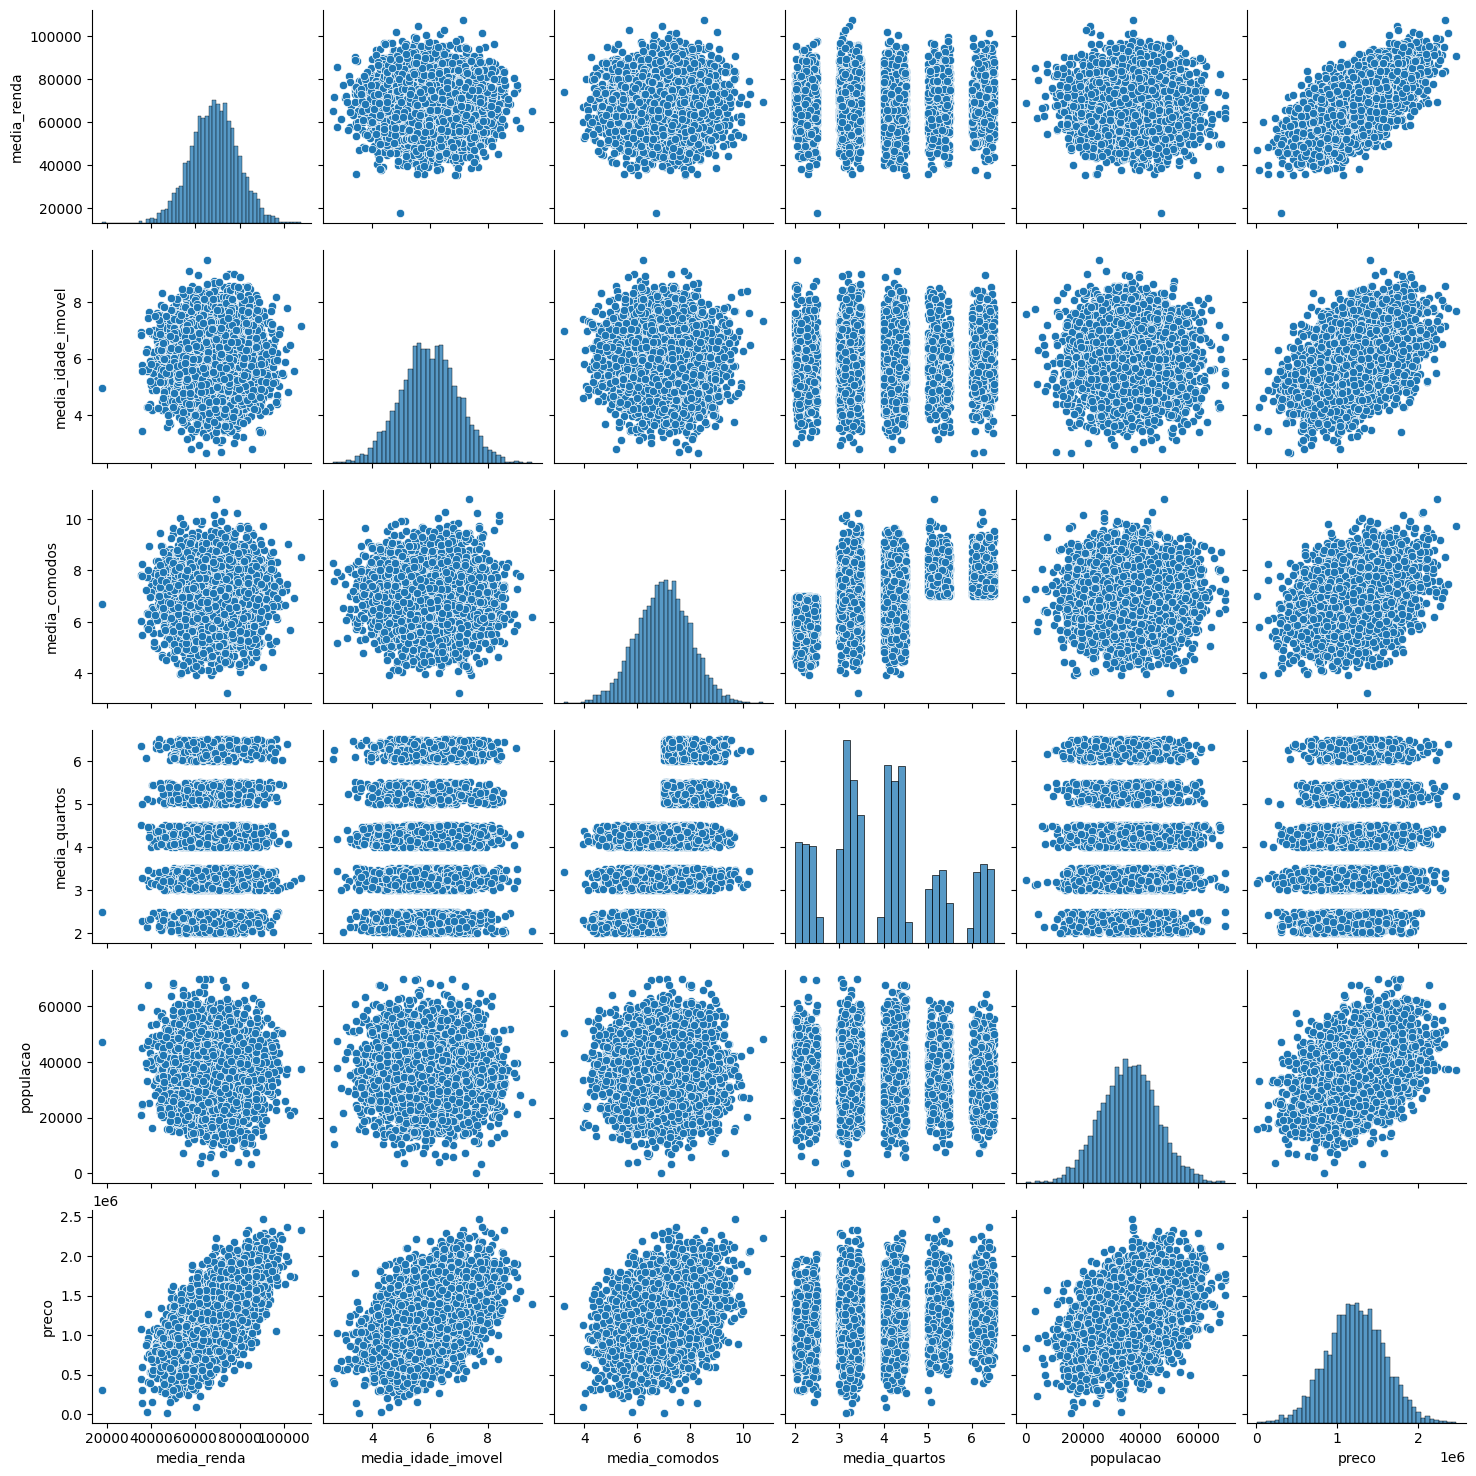

In [ ]:
# Para identificar como os dados se relacionam. Como queremos estudar a regressão sobre o preço do imóvel, vamos analisar a linha ou coluna do 'preco'
sns.pairplot(USAHousing)

# Ao analisar os gráfico de pares, foi possível identificar visualmente que tem uma regressão. Mas, é claro, existem técnicas avançadas para identificar isso e chegar
#  em uma conclusão definitiva.

<Axes: >

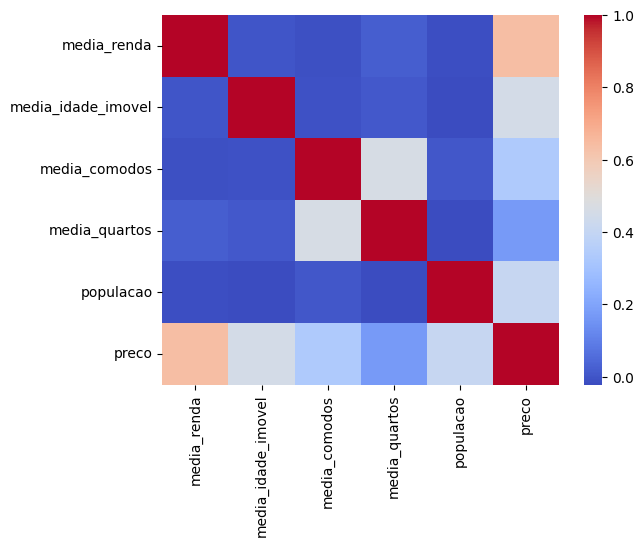

In [41]:
# Gráfico de calor para visualizar as correlações das variáveis.
sns.heatmap(USAHousing.corr(), cmap='coolwarm')

## Preparando para usar regressão linear

In [42]:
# Agora vou separar as variáveis preditoras (features) da variável target 'preco'.
X = USAHousing[['media_renda', 'media_idade_imovel', 'media_comodos', 'media_quartos', 'populacao']]
y = USAHousing[['preco']]

In [45]:
# O train_test_split divide seu conjunto de dados (geralmente X e y) em dois subconjuntos:
# Treinamento, usado para treinar o modelo;
# Teste, usado para avaliar o modelo com dados que ele nunca viu antes.
from sklearn.model_selection import train_test_split

# test_size: Percentual (ou número) de dados para o conjunto de teste. Ex: 0.33 = 33%
# random_state: Define uma seed para reproduzir separação identica em execuções distintas (inteiro).
# shuffle: embaralha os dados antes de dividir (True ou False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, shuffle=False)

In [ ]:
# Visualização interativa por trás do train_test_split
print(f"DF Original: {len(USAHousing)}")
print(f"X Treino:    {len(X_train)}")
print(f"y Treino:    {len(y_train)}")
print(f"X Teste:     {len(X_test)}")
print(f"y Teste:     {len(y_test)}")
print()
print(f"X Treino + X Teste: {len(X_train) + len(X_test)}")
print(f"33% do DF Original: {int(len(USAHousing) * 0.33)}")

DF Original: 5000
X Treino:    3350
y Treino:    3350
X Teste:     1650
y Teste:     1650

X Treino + X Teste: 5000
33% do DF Original: 1650


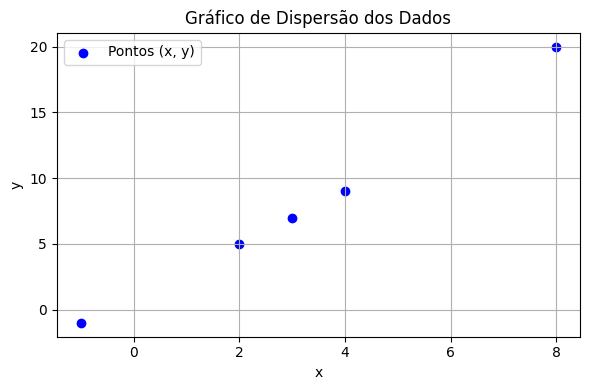

In [12]:
# Gráfico plotado está sendo usando na apostila.

# Dados da tabela
x = [3, 2, -1, 4, 8]
y = [7, 5, -1, 9, 20]

# Criar o gráfico de dispersão
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Pontos (x, y)')
plt.title('Gráfico de Dispersão dos Dados')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()